In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,cross_val_score, GridSearchCV
from sklearn.svm import SVC, LinearSVC

In [3]:
import keras
from keras.models import Sequential


In [4]:
df= pd.read_csv("cleaned_cardio.csv")
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62,110,80,1,1,0,0,1,0
1,1,20228,1,156,85,140,90,3,1,0,0,1,1
2,2,18857,1,165,64,130,70,3,1,0,0,0,1
3,3,17623,2,169,82,150,100,1,1,0,0,1,1
4,4,17474,1,156,56,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72,135,80,1,2,0,0,0,1


<Axes: xlabel='years', ylabel='count'>

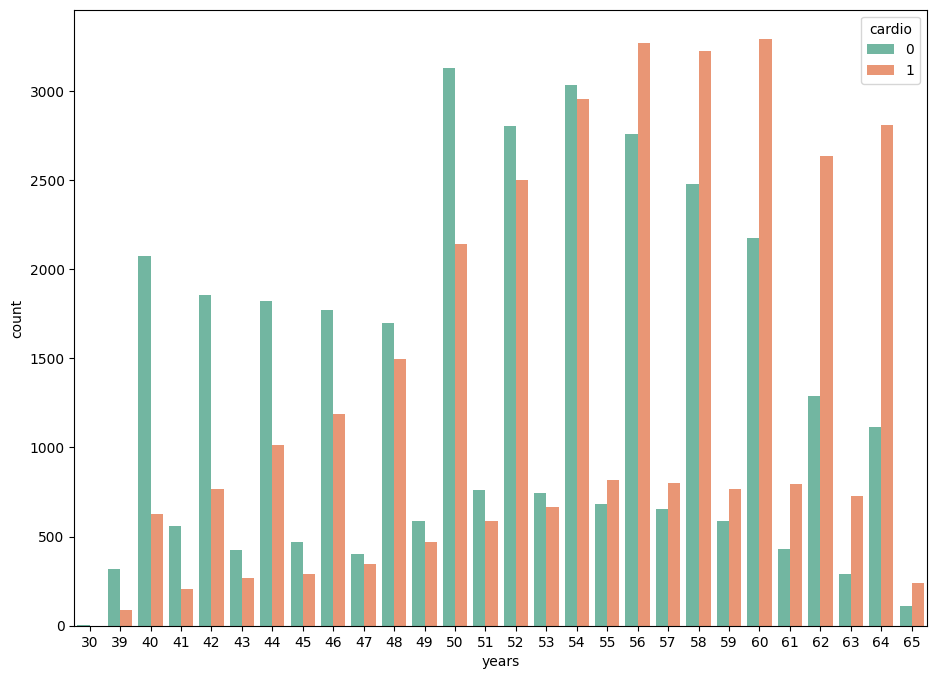

In [5]:
from matplotlib import rcParams
rcParams['figure.figsize'] = 11, 8
df['years'] = (df['age'] / 365).round().astype('int')
sns.countplot(x='years', hue='cardio', data = df, palette="Set2")

The graph shows that as the age increases of the person the risk of having a cardio-vascular disease increases

```
`# This is formatted as code`
```



<Axes: xlabel='variable', ylabel='count'>

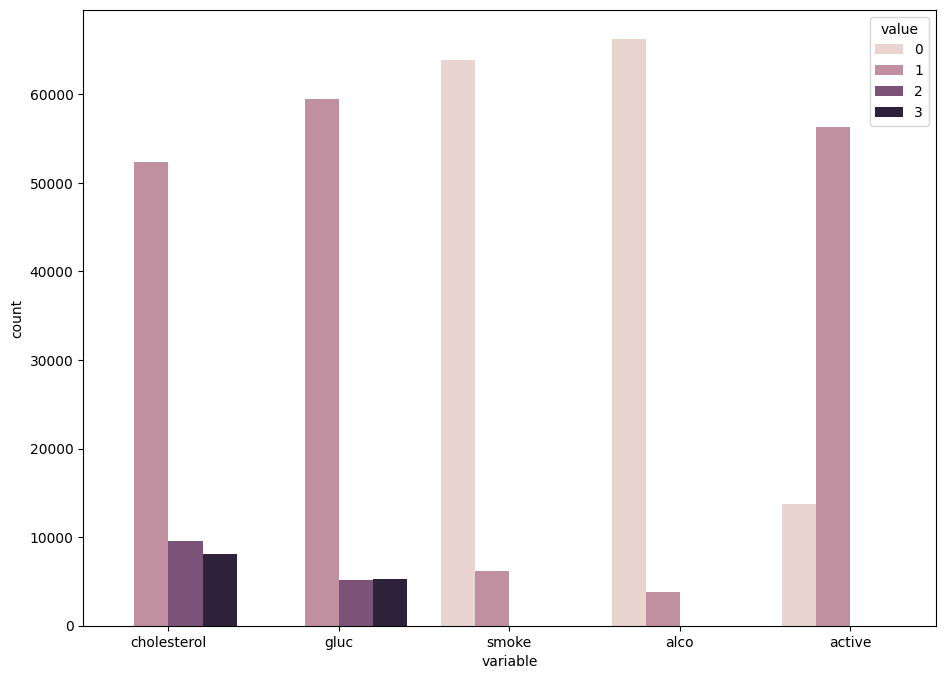

In [6]:
df_categorical = df.loc[:,['cholesterol','gluc', 'smoke', 'alco', 'active']]
sns.countplot(x="variable", hue="value",data= pd.melt(df_categorical))


**Cleaning of the Data**

In [7]:
df.isnull().values.any()
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,years
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205543,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700,53.338686
std,28851.302323,2467.251667,0.476838,8.210126,14.395829,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003,6.765294
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,30.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,54.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,65.000000


In [8]:
df.drop(df[(df['height'] > df['height'].quantile(0.975)) | (df['height'] < df['height'].quantile(0.025))].index,inplace=True)
df.drop(df[(df['weight'] > df['weight'].quantile(0.975)) | (df['weight'] < df['weight'].quantile(0.025))].index,inplace=True)

In [9]:
print("Diastilic pressure is higher than systolic one in {0} cases".format(df[df['ap_lo']> df['ap_hi']].shape[0]))

Diastilic pressure is higher than systolic one in 1082 cases


In [10]:
df.drop(df[(df['ap_hi'] > df['ap_hi'].quantile(0.975)) | (df['ap_hi'] < df['ap_hi'].quantile(0.025))].index,inplace=True)
df.drop(df[(df['ap_lo'] > df['ap_lo'].quantile(0.975)) | (df['ap_lo'] < df['ap_lo'].quantile(0.025))].index,inplace=True)

In [11]:
df.dropna()
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,years
0,0,18393,2,168,62,110,80,1,1,0,0,1,0,50
1,1,20228,1,156,85,140,90,3,1,0,0,1,1,55
2,2,18857,1,165,64,130,70,3,1,0,0,0,1,52
3,3,17623,2,169,82,150,100,1,1,0,0,1,1,48
4,4,17474,1,156,56,100,60,1,1,0,0,0,0,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,99991,19699,1,172,70,130,90,1,1,0,0,1,1,54
69994,99992,21074,1,165,80,150,80,1,1,0,0,1,1,58
69995,99993,19240,2,168,76,120,80,1,1,1,0,1,0,53
69998,99998,22431,1,163,72,135,80,1,2,0,0,0,1,61


In [12]:
df_sampled = df.sample(frac=0.8, random_state=42)
df_remaining = df.drop(df_sampled.index)
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,years
0,0,18393,2,168,62,110,80,1,1,0,0,1,0,50
1,1,20228,1,156,85,140,90,3,1,0,0,1,1,55
2,2,18857,1,165,64,130,70,3,1,0,0,0,1,52
3,3,17623,2,169,82,150,100,1,1,0,0,1,1,48
4,4,17474,1,156,56,100,60,1,1,0,0,0,0,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,99991,19699,1,172,70,130,90,1,1,0,0,1,1,54
69994,99992,21074,1,165,80,150,80,1,1,0,0,1,1,58
69995,99993,19240,2,168,76,120,80,1,1,1,0,1,0,53
69998,99998,22431,1,163,72,135,80,1,2,0,0,0,1,61


In [13]:
frac_to_drop = 0.7 + (0.1 * np.random.rand())  # Randomly choose a value between 70% and 80%
df_remaining = df.sample(frac=1-frac_to_drop, random_state=42)

df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,years
0,0,18393,2,168,62,110,80,1,1,0,0,1,0,50
1,1,20228,1,156,85,140,90,3,1,0,0,1,1,55
2,2,18857,1,165,64,130,70,3,1,0,0,0,1,52
3,3,17623,2,169,82,150,100,1,1,0,0,1,1,48
4,4,17474,1,156,56,100,60,1,1,0,0,0,0,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,99991,19699,1,172,70,130,90,1,1,0,0,1,1,54
69994,99992,21074,1,165,80,150,80,1,1,0,0,1,1,58
69995,99993,19240,2,168,76,120,80,1,1,1,0,1,0,53
69998,99998,22431,1,163,72,135,80,1,2,0,0,0,1,61


In [14]:
df["age"] = df["years"]
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,years
0,0,50,2,168,62,110,80,1,1,0,0,1,0,50
1,1,55,1,156,85,140,90,3,1,0,0,1,1,55
2,2,52,1,165,64,130,70,3,1,0,0,0,1,52
3,3,48,2,169,82,150,100,1,1,0,0,1,1,48
4,4,48,1,156,56,100,60,1,1,0,0,0,0,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,99991,54,1,172,70,130,90,1,1,0,0,1,1,54
69994,99992,58,1,165,80,150,80,1,1,0,0,1,1,58
69995,99993,53,2,168,76,120,80,1,1,1,0,1,0,53
69998,99998,61,1,163,72,135,80,1,2,0,0,0,1,61


In [15]:
df.drop("years",axis = 1)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62,110,80,1,1,0,0,1,0
1,1,55,1,156,85,140,90,3,1,0,0,1,1
2,2,52,1,165,64,130,70,3,1,0,0,0,1
3,3,48,2,169,82,150,100,1,1,0,0,1,1
4,4,48,1,156,56,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,99991,54,1,172,70,130,90,1,1,0,0,1,1
69994,99992,58,1,165,80,150,80,1,1,0,0,1,1
69995,99993,53,2,168,76,120,80,1,1,1,0,1,0
69998,99998,61,1,163,72,135,80,1,2,0,0,0,1


In [16]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,years
0,0,50,2,168,62,110,80,1,1,0,0,1,0,50
1,1,55,1,156,85,140,90,3,1,0,0,1,1,55
2,2,52,1,165,64,130,70,3,1,0,0,0,1,52
3,3,48,2,169,82,150,100,1,1,0,0,1,1,48
4,4,48,1,156,56,100,60,1,1,0,0,0,0,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,99991,54,1,172,70,130,90,1,1,0,0,1,1,54
69994,99992,58,1,165,80,150,80,1,1,0,0,1,1,58
69995,99993,53,2,168,76,120,80,1,1,1,0,1,0,53
69998,99998,61,1,163,72,135,80,1,2,0,0,0,1,61


In [17]:
df.rename(columns = {'cardio':'Target'}, inplace = True)
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,Target,years
0,0,50,2,168,62,110,80,1,1,0,0,1,0,50
1,1,55,1,156,85,140,90,3,1,0,0,1,1,55
2,2,52,1,165,64,130,70,3,1,0,0,0,1,52
3,3,48,2,169,82,150,100,1,1,0,0,1,1,48
4,4,48,1,156,56,100,60,1,1,0,0,0,0,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,99991,54,1,172,70,130,90,1,1,0,0,1,1,54
69994,99992,58,1,165,80,150,80,1,1,0,0,1,1,58
69995,99993,53,2,168,76,120,80,1,1,1,0,1,0,53
69998,99998,61,1,163,72,135,80,1,2,0,0,0,1,61


In [18]:
df.tail()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,Target,years
69993,99991,54,1,172,70,130,90,1,1,0,0,1,1,54
69994,99992,58,1,165,80,150,80,1,1,0,0,1,1,58
69995,99993,53,2,168,76,120,80,1,1,1,0,1,0,53
69998,99998,61,1,163,72,135,80,1,2,0,0,0,1,61
69999,99999,56,1,170,72,120,80,2,1,0,0,1,0,56


In [19]:
df.drop('years',axis =1,inplace =True)
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,Target
0,0,50,2,168,62,110,80,1,1,0,0,1,0
1,1,55,1,156,85,140,90,3,1,0,0,1,1
2,2,52,1,165,64,130,70,3,1,0,0,0,1
3,3,48,2,169,82,150,100,1,1,0,0,1,1
4,4,48,1,156,56,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,99991,54,1,172,70,130,90,1,1,0,0,1,1
69994,99992,58,1,165,80,150,80,1,1,0,0,1,1
69995,99993,53,2,168,76,120,80,1,1,1,0,1,0
69998,99998,61,1,163,72,135,80,1,2,0,0,0,1


In [20]:
Y = df.Target
X = df.drop('Target', axis=1)
X
Y

,Target
0,0
1,1
2,1
3,1
4,0
...,...
69993,1
69994,1
69995,0
69998,1


In [21]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,Target
count,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000,60145.000000
mean,49895.586000,53.339064,1.347294,164.554693,73.427351,125.770737,81.046587,1.350968,1.220218,0.085626,0.051891,0.803658,0.488253
std,28840.654627,6.746942,0.476114,6.830067,11.616460,13.761536,8.239114,0.670096,0.567595,0.279814,0.221809,0.397234,0.499866
min,0.000000,30.000000,1.000000,150.000000,52.000000,100.000000,60.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,24866.000000,48.000000,1.000000,160.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,49903.000000,54.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74746.000000,58.000000,2.000000,169.000000,80.000000,135.000000,90.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,65.000000,2.000000,180.000000,106.000000,163.000000,100.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [22]:
train, test, target, target_test = train_test_split(X,Y,test_size = 0.2,stratify=Y,random_state=2)



In [23]:
train.drop

<bound method DataFrame.drop of           id  age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  \
44384  63391   44       1     166      85    110     80            1     1   
14413  20588   46       2     161      64    120     80            1     1   
57135  81560   54       1     162      60    150     90            1     1   
23796  34015   55       1     158      82    160     90            2     2   
47169  67372   44       2     164      84    130     87            1     1   
...      ...  ...     ...     ...     ...    ...    ...          ...   ...   
29990  42884   58       2     162      74    120     80            1     1   
24058  34387   52       2     178      82    130     70            1     1   
63631  90854   56       1     161      75    130     80            1     1   
65888  94050   62       1     162      65    120     80            1     1   
64480  92048   47       1     168      79    150     90            1     1   

       smoke  alco  active  
44384      0     0       1  
14413      1     0       1  
57135      0     0       1  
23796      0     0       1  
47169      0     1       1  
...      ...   ...     ...  
29990      0     0       1  
24058      0     0       1  
63631      0     0       1  
65888      0     0       1  
64480      0     0       1  

[48116 rows x 12 columns]>

In [24]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,Target
0,0,50,2,168,62,110,80,1,1,0,0,1,0
1,1,55,1,156,85,140,90,3,1,0,0,1,1
2,2,52,1,165,64,130,70,3,1,0,0,0,1
3,3,48,2,169,82,150,100,1,1,0,0,1,1
4,4,48,1,156,56,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69993,99991,54,1,172,70,130,90,1,1,0,0,1,1
69994,99992,58,1,165,80,150,80,1,1,0,0,1,1
69995,99993,53,2,168,76,120,80,1,1,1,0,1,0
69998,99998,61,1,163,72,135,80,1,2,0,0,0,1


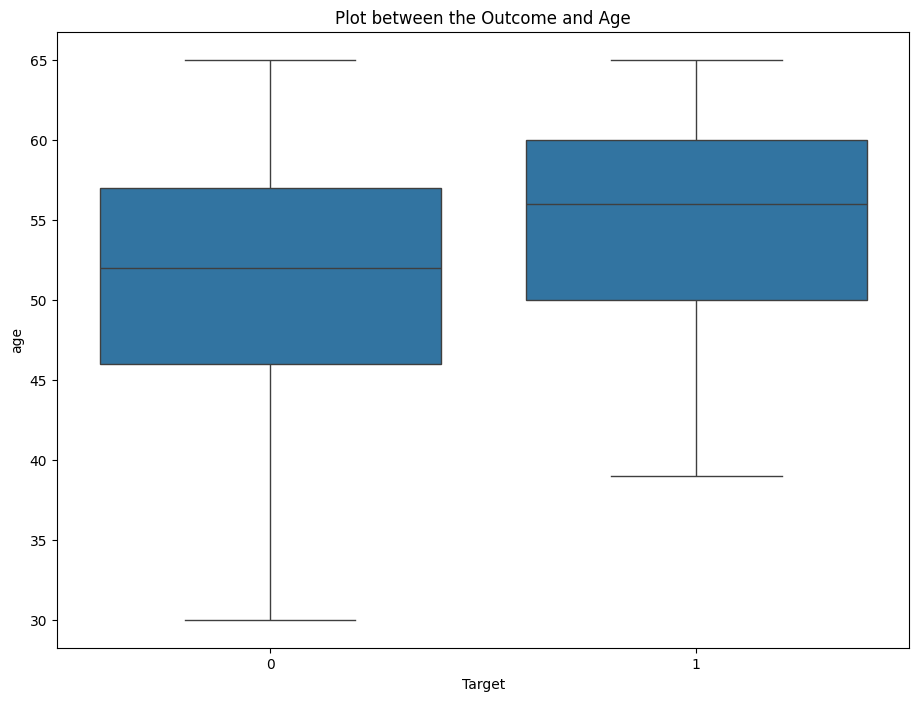

In [25]:
sns.boxplot(x='Target', y='age', data=df)
plt.title('Plot between the Outcome and Age')
plt.show()


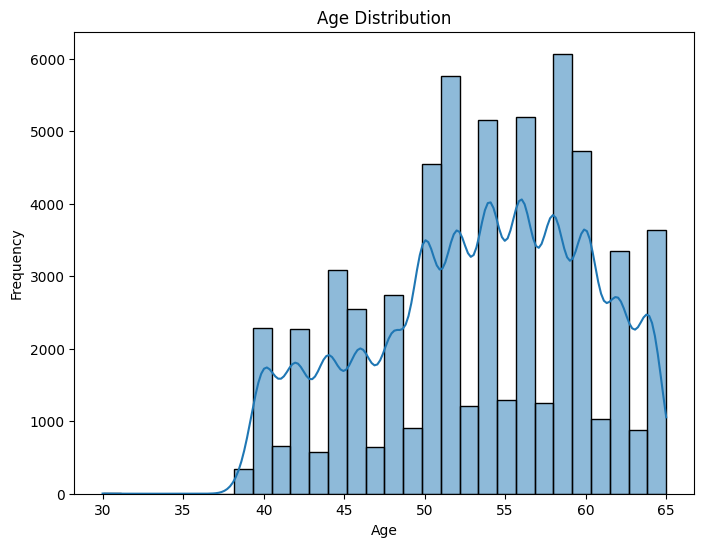

In [26]:
plt.figure(figsize=(8, 6))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Text(0.5, 1.0, 'Glucose Level Distribution')

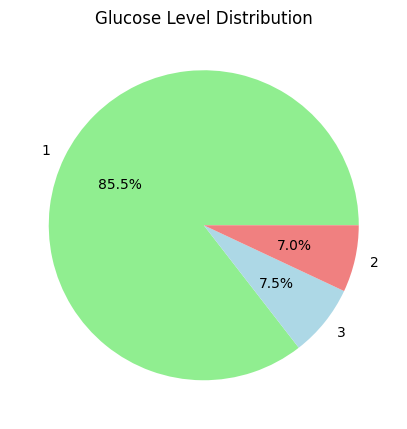

In [27]:
plt.subplot(1, 2, 2)
gluc_counts = df['gluc'].value_counts()
plt.pie(gluc_counts, labels=gluc_counts.index, autopct='%1.1f%%', colors=['lightgreen','lightblue', 'lightcoral'])
plt.title('Glucose Level Distribution')

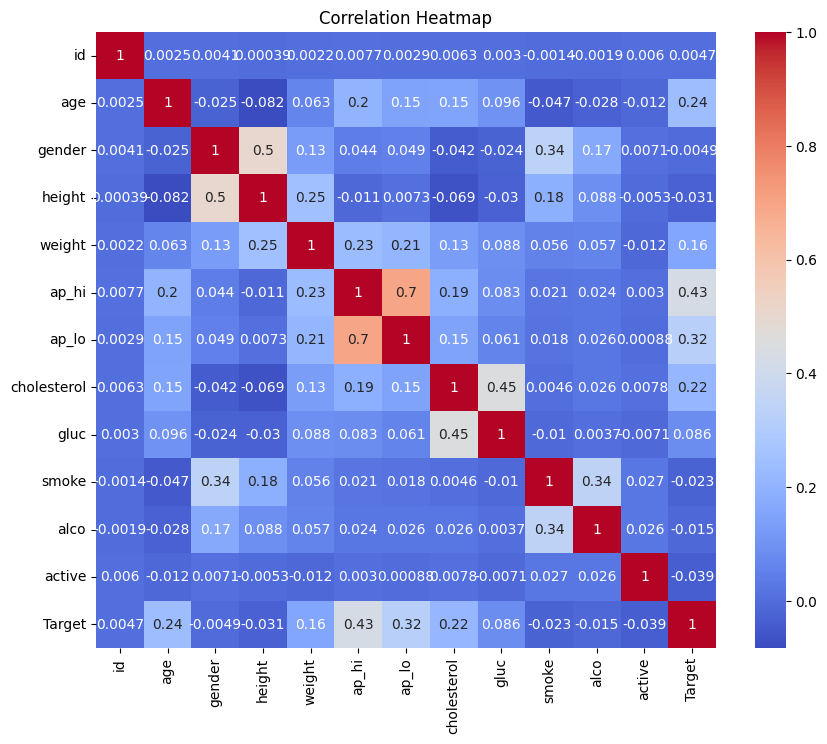

In [28]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Pair Plot to show the relation betwwen each column

In [29]:
sns.pairplot(data=df, hue="gender", diag_kind="kde", palette="husl")
plt.title("Iris Dataset Pair Plot")
plt.show()

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7d24af32c860> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7d24af2b0fe0> (for post_execute):


KeyboardInterrupt: 

In [30]:
train, test, target, target_test = train_test_split(X,Y,test_size = 0.2,stratify=Y,random_state=2)


In [31]:
train.drop

<bound method DataFrame.drop of           id  age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  \
44384  63391   44       1     166      85    110     80            1     1   
14413  20588   46       2     161      64    120     80            1     1   
57135  81560   54       1     162      60    150     90            1     1   
23796  34015   55       1     158      82    160     90            2     2   
47169  67372   44       2     164      84    130     87            1     1   
...      ...  ...     ...     ...     ...    ...    ...          ...   ...   
29990  42884   58       2     162      74    120     80            1     1   
24058  34387   52       2     178      82    130     70            1     1   
63631  90854   56       1     161      75    130     80            1     1   
65888  94050   62       1     162      65    120     80            1     1   
64480  92048   47       1     168      79    150     90            1     1   

       smoke  alco  active  
44384      0     0       1  
14413      1     0       1  
57135      0     0       1  
23796      0     0       1  
47169      0     1       1  
...      ...   ...     ...  
29990      0     0       1  
24058      0     0       1  
63631      0     0       1  
65888      0     0       1  
64480      0     0       1  

[48116 rows x 12 columns]>

In [32]:
Xtrain, Xval, Ztrain, Zval = train_test_split(train, target, test_size=0.2, random_state=0)

**Model training**
Logistic Regression

In [33]:
logreg = LogisticRegression()
logreg.fit(train, target)
acc_log = round(logreg.score(train, target) * 100, 2)
acc_log

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


69.83

In [34]:
acc_test_log = round(logreg.score(test, target_test) * 100, 2)
acc_test_log

coeff_df = pd.DataFrame(train.columns.delete(0))
coeff_df.columns = ['Feature']
coeff_df["Correlation"] = pd.Series(logreg.coef_[0])
coeff_df.sort_values(by='Correlation', ascending=False)

,Feature,Correlation
5,ap_lo,5.762089e-02
1,gender,3.835685e-02
4,ap_hi,1.760050e-02
7,gluc,8.038965e-03
6,cholesterol,1.928607e-03
8,smoke,1.650767e-03
2,height,1.379222e-03
0,age,-4.164505e-07
9,alco,-2.497332e-04
10,active,-2.979987e-04


**Predictive Model**-Random Forest

In [35]:
random_forest = GridSearchCV(estimator=RandomForestClassifier(), param_grid={'n_estimators': [100, 300]}, cv=5).fit(train, target)
random_forest.fit(train, target)
acc_random_forest = round(random_forest.score(train, target) * 100, 2)
print(acc_random_forest,random_forest.best_params_)

100.0 {'n_estimators': 300}


In [36]:
acc_test_random_forest = round(random_forest.score(test, target_test) * 100, 2)
acc_test_random_forest

70.95

Training and Testing scores of Logistic Regression and Random Forest

In [37]:
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', ],

    'Score_train': [acc_log,    acc_random_forest],

    'Score_test': [acc_test_log, acc_test_random_forest, ]
})

models

,Model,Score_train,Score_test
0,Logistic Regression,69.83,68.86
1,Random Forest,100.00,70.95


Input of the data that is to be predicted

In [47]:
input_data = []
name = input("Enter your name: ")
id = int(input("Enter id number of person: "))
age = int(input("Enter age of person: "))
gender = int(input("Enter gender of person {for male : 1 ; for female : 2}:  "))
height = int(input("Enter height of person in cm: "))
weight = int(input("Enter weight of person in kgs: "))
systolic = int(input("Enter systolic blood pressure of person in mmHg: "))
diastolic = int(input("Enter diastolic blood pressure of person in mmHg: "))
cholesterol = int(input("Enter cholesterol of person in level:1 to 3: "))
glucose = int(input("Enter glucose level of person in level:1 to 3:: "))
smoker = int(input("Does the person smoke? {Yes: 1; No: 0}: "))
alcoholic = int(input("Is the person alcoholic? {Yes: 1; No: 0}: "))
physically_fit = int(input("Is the person physically active? {Yes: 1; No: 0}: "))

input_data.append(id)
input_data.append(age)
input_data.append(gender)
input_data.append(height)
input_data.append(weight)
input_data.append(systolic)
input_data.append(diastolic)
input_data.append(cholesterol)
input_data.append(glucose)
input_data.append(smoker)
input_data.append(alcoholic)
input_data.append(physically_fit)

id = input_data[0]
age = input_data[1]
gender = input_data[2]
height = input_data[3]
weight = input_data[4]
systolic = input_data[5]
diastolic = input_data[6]
cholesterol = input_data[7]
glucose = input_data[8]
smoker = input_data[9]
alcoholic = input_data[10]
physically_fit = input_data[11]

Enter your name: Nayna Baghel
Enter id number of person: 05
Enter age of person: 24
Enter gender of person {for male : 1 ; for female : 2}:  2
Enter height of person in cm: 162
Enter weight of person in kgs: 52
Enter systolic blood pressure of person in mmHg: 85
Enter diastolic blood pressure of person in mmHg: 75
Enter cholesterol of person in level:1 to 3: 2
Enter glucose level of person in level:1 to 3:: 2
Does the person smoke? {Yes: 1; No: 0}: 0
Is the person alcoholic? {Yes: 1; No: 0}: 0
Is the person physically active? {Yes: 1; No: 0}: 0


In [48]:
input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

In [49]:
print(" *** WELCOME TO HEART DISEASE PREDICTOR ***")
print("-----------------------------------------------------")
print("Name of person: ",name)
print("-----------------------------------------------------")
print("id: ", id)
print("-----------------------------------------------------")
print("age:" , age)
print("-----------------------------------------------------")
if gender ==1:
    print("gender: male")
else:
    print("gender: female")
print("-----------------------------------------------------")
print("weight: ", weight)
print("-----------------------------------------------------")
print("systolic blood pressure: ", systolic)
print("-----------------------------------------------------")
print("diastolic blood pressure: ", diastolic)
print("-----------------------------------------------------")
print("cholesterol: ", cholesterol)
print("-----------------------------------------------------")
print("blood glucose level: ", glucose)
print("-----------------------------------------------------")

if smoker == 1:
  print("is he/she a smoker?: yes")
else:
  print("is he/she a smoker?: no")
print("-----------------------------------------------------")
if smoker == 1:
  print("is he/she a alcoholic?: yes")
else:
  print("is he/she a alcoholic?: no")

print("-----------------------------------------------------")
if physically_fit ==1:
  print("does he/she do any physical activity?: yes")
else:
  print("does he/she do any physical activity?: no")
print("-----------------------------------------------------")

 *** WELCOME TO HEART DISEASE PREDICTOR ***
-----------------------------------------------------
Name of person:  Nayna Baghel
-----------------------------------------------------
id:  5
-----------------------------------------------------
age: 24
-----------------------------------------------------
gender: female
-----------------------------------------------------
weight:  52
-----------------------------------------------------
systolic blood pressure:  85
-----------------------------------------------------
diastolic blood pressure:  75
-----------------------------------------------------
cholesterol:  2
-----------------------------------------------------
blood glucose level:  2
-----------------------------------------------------
is he/she a smoker?: no
-----------------------------------------------------
is he/she a alcoholic?: no
-----------------------------------------------------
does he/she do any physical activity?: no
--------------------------------------------

In [52]:
import math

score = 0

if age >= 40:
  score += 1
elif age >= 50:
  score += 2

if gender == 1:
  score += 2
else:
  score += 1

h = height/100
bmi = weight / (h*h)

if bmi >= 40:
  score += 2
elif bmi >= 30:
  score += 1

if systolic in range(130,140) and diastolic in range(80,90):
  score += 1
elif systolic >= 140 and diastolic >= 90:
  score += 2

score += (cholesterol + glucose + smoker + alcoholic + physically_fit)

percentage = (score/16)*100

prediction = random_forest.predict(input_data_reshaped)

if (prediction[0] == 0):
    print('Person does not have heart disease.')
else:
    print('Person may have or may develop a heart disease in the future if this lifestyle is continued.')
print("-----------------------------------------------------")
print("Chances of cardiovascular disease: ", math.ceil(percentage*100)/100, "%")
print("-----------------------------------------------------")

Person does not have heart disease.
-----------------------------------------------------
Chances of cardiovascular disease:  31.25 %
-----------------------------------------------------


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
